In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Bacteria

**This section has the differental panels generated for Figure 1 in the manuscript**

## Defense systems Bacteria plot

Saved in DataFrame: `defense_systems_wide`

In [ ]:
# prompt: read the xlsx file

# Assuming the xlsx file is in the current working directory or provide the full path
file_path = 'TableS3-defenseSystems.xlsx'  # Replace 'your_file.xlsx' with the actual filename

try:
    data = pd.read_excel(file_path)
    defense_systems = pd.DataFrame(data)
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")
defense_systems

,bacteria,sys_id,type,subtype,activity,sys_beg,sys_end,protein_in_syst,genes_count,name_of_profiles_in_sys
0,A. xylosoxidans jini,jini-9475_Hna_1,Hna,Hna,Defense,AONLIA_04279,AONLIA_04279,AONLIA_04279,1,Hna__Hna
1,A. xylosoxidans ayb,NaN,NaN,NaN,Defense,NaN,NaN,NaN,0,NaN
2,A. xylosoxidans suz,suz-2089_AbiU_1,AbiU,AbiU,Defense,BLEAJA_00087,BLEAJA_00087,BLEAJA_00087,1,AbiU__AbiU
3,A. xylosoxidans suz,suz-2089_RM_Type_II_4,RM,RM_Type_II,Defense,BLEAJA_02122,BLEAJA_02123,"BLEAJA_02122,BLEAJA_02123",2,"RM_Type_II__Type_II_MTases,RM_Type_II__Type_II..."
4,A. xylosoxidans suz,suz-2089_RM_Type_I_3,RM,RM_Type_I,Defense,BLEAJA_05286,BLEAJA_05291,"BLEAJA_05286,BLEAJA_05291",2,"RM__Type_I_MTases,RM__Type_I_REases"
5,A. xylosoxidans suz,suz-2089_PD-T7-1_2,PD-T7-1,PD-T7-1,Defense,BLEAJA_05484,BLEAJA_05485,"BLEAJA_05484,BLEAJA_05485",2,"PD-T7-1__PD-T7-1,PD-T7-1__PD-T7-1"
6,A. insolitus vya,vya-6884_CBASS_II_5,CBASS,CBASS_II,Defense,OKFHJP_00831,OKFHJP_00833,"OKFHJP_00831,OKFHJP_00832,OKFHJP_00833",3,"CBASS__AG_E1_ThiF,CBASS__Cyclase_II,CBASS__Pho..."
7,A. insolitus vya,vya-6884_Kiwa_1,Kiwa,Kiwa,Defense,OKFHJP_02245,OKFHJP_02246,"OKFHJP_02245,OKFHJP_02246",2,"Kiwa__KwaA,Kiwa__KwaB_2"
8,A. insolitus vya,vya-6884_Shedu_2,Shedu,Shedu,Defense,OKFHJP_07652,OKFHJP_07652,OKFHJP_07652,1,Shedu__SduA
9,A. insolitus neet,neet-reseq_CBASS_II_7,CBASS,CBASS_II,Defense,LFJAJO_00770,LFJAJO_00780,"LFJAJO_00770,LFJAJO_00777,LFJAJO_00779,LFJAJO_...",4,"CBASS__AG_E1_ThiF,CBASS__Cyclase_II,CBASS__Eff..."


In [ ]:
y_order=['A. insolitus aura', 'A. insolitus cram', 'A. insolitus neet',	'A. insolitus vya', 'A. xylosoxidans ayb', 'A. xylosoxidans jini', 'A. xylosoxidans suz']
defense_systems["bacteria"] = pd.Categorical(defense_systems["bacteria"], categories=y_order, ordered=True)
defense_systems

,bacteria,sys_id,type,subtype,activity,sys_beg,sys_end,protein_in_syst,genes_count,name_of_profiles_in_sys
0,A. xylosoxidans jini,jini-9475_Hna_1,Hna,Hna,Defense,AONLIA_04279,AONLIA_04279,AONLIA_04279,1,Hna__Hna
1,A. xylosoxidans ayb,NaN,NaN,NaN,Defense,NaN,NaN,NaN,0,NaN
2,A. xylosoxidans suz,suz-2089_AbiU_1,AbiU,AbiU,Defense,BLEAJA_00087,BLEAJA_00087,BLEAJA_00087,1,AbiU__AbiU
3,A. xylosoxidans suz,suz-2089_RM_Type_II_4,RM,RM_Type_II,Defense,BLEAJA_02122,BLEAJA_02123,"BLEAJA_02122,BLEAJA_02123",2,"RM_Type_II__Type_II_MTases,RM_Type_II__Type_II..."
4,A. xylosoxidans suz,suz-2089_RM_Type_I_3,RM,RM_Type_I,Defense,BLEAJA_05286,BLEAJA_05291,"BLEAJA_05286,BLEAJA_05291",2,"RM__Type_I_MTases,RM__Type_I_REases"
5,A. xylosoxidans suz,suz-2089_PD-T7-1_2,PD-T7-1,PD-T7-1,Defense,BLEAJA_05484,BLEAJA_05485,"BLEAJA_05484,BLEAJA_05485",2,"PD-T7-1__PD-T7-1,PD-T7-1__PD-T7-1"
6,A. insolitus vya,vya-6884_CBASS_II_5,CBASS,CBASS_II,Defense,OKFHJP_00831,OKFHJP_00833,"OKFHJP_00831,OKFHJP_00832,OKFHJP_00833",3,"CBASS__AG_E1_ThiF,CBASS__Cyclase_II,CBASS__Pho..."
7,A. insolitus vya,vya-6884_Kiwa_1,Kiwa,Kiwa,Defense,OKFHJP_02245,OKFHJP_02246,"OKFHJP_02245,OKFHJP_02246",2,"Kiwa__KwaA,Kiwa__KwaB_2"
8,A. insolitus vya,vya-6884_Shedu_2,Shedu,Shedu,Defense,OKFHJP_07652,OKFHJP_07652,OKFHJP_07652,1,Shedu__SduA
9,A. insolitus neet,neet-reseq_CBASS_II_7,CBASS,CBASS_II,Defense,LFJAJO_00770,LFJAJO_00780,"LFJAJO_00770,LFJAJO_00777,LFJAJO_00779,LFJAJO_...",4,"CBASS__AG_E1_ThiF,CBASS__Cyclase_II,CBASS__Eff..."


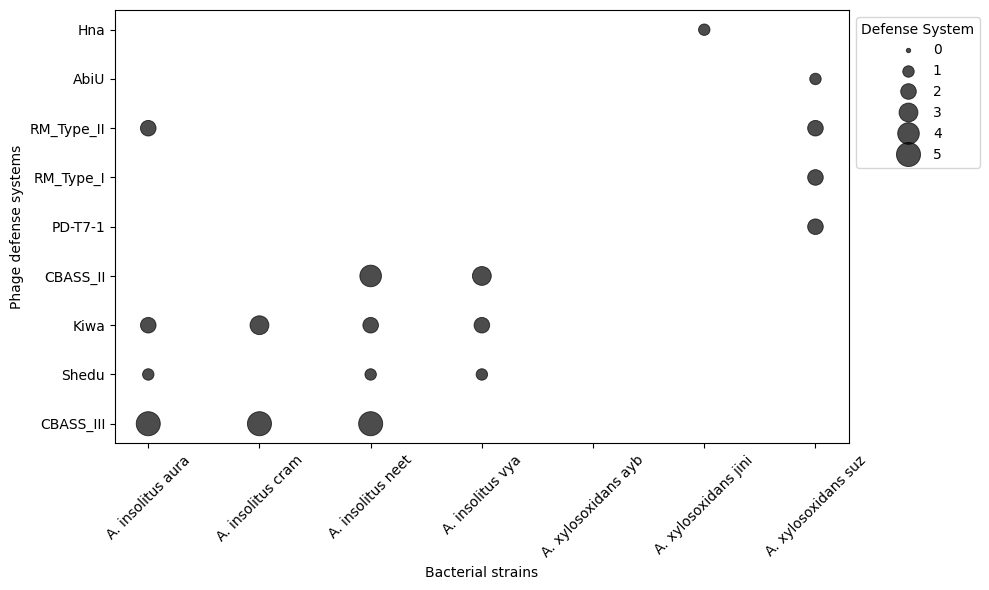

In [ ]:
# Create bubble plot
plt.figure(figsize=(10, 6))

# Create bubble plot using scatter
sns.scatterplot(
    x=defense_systems["bacteria"],
    y=defense_systems["subtype"],
    size=defense_systems["genes_count"],
    sizes=(10, 300),
    edgecolor="black",
    alpha=0.7,
    color="black"
)

# Customize plot aesthetics
plt.xlabel("Bacterial strains")
plt.ylabel("Phage defense systems")
plt.xticks(rotation=45)
plt.legend(title="Defense System", bbox_to_anchor=(1, 1), loc='upper left')

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
defense_systems_wide = defense_systems.pivot_table(index='bacteria',
                                                   columns='subtype',
                                                   values='genes_count',
                                                   aggfunc='sum',
                                                   fill_value=0)

# Display the wide-format DataFrame
defense_systems_wide.loc["A. xylosoxidans ayb"] = 0

# Ensure all values remain integers (if applicable)
defense_systems_wide = defense_systems_wide.astype(int)

defense_systems_wide

/tmp/ipython-input-3851301552.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  defense_systems_wide = defense_systems.pivot_table(index='bacteria',


subtype,AbiU,CBASS_II,CBASS_III,Hna,Kiwa,PD-T7-1,RM_Type_I,RM_Type_II,Shedu
bacteria,,,,,,,,,
A. insolitus aura,0,0,5,0,2,0,0,2,1
A. insolitus cram,0,0,5,0,3,0,0,0,0
A. insolitus neet,0,4,5,0,2,0,0,0,1
A. insolitus vya,0,3,0,0,2,0,0,0,1
A. xylosoxidans ayb,0,0,0,0,0,0,0,0,0
A. xylosoxidans jini,0,0,0,1,0,0,0,0,0
A. xylosoxidans suz,1,0,0,0,0,2,2,2,0


## AMR Finder results

DataFrame saved to `amrfinder_wide`

In [ ]:
amrfinder=pd.read_csv("amrfinderplus_all.tsv", sep='\t')
amrfinder

,sample,Protein id,Contig id,genome,Start,Stop,Strand,Element symbol,Element name,Scope,...,Class,Subclass,Method,Target length,Reference sequence length,% Coverage of reference,% Identity to reference,Alignment length,Closest reference accession,Closest reference name
0,A. insolitus aura,HKHFHI_02966,contig_1,chromosome,2284402,2285331,+,ampC,class C beta-lactamase,core,...,BETA-LACTAM,BETA-LACTAM,HMM,309,396,72.98,70.59,289,WP_280147732.1,class C beta-lactamase
1,A. insolitus aura,HKHFHI_03711,contig_1,chromosome,2885124,2886359,-,tet,Tet(A)/Tet(B)/Tet(C) family tetracycline efflu...,core,...,TETRACYCLINE,TETRACYCLINE,HMM,411,399,95.74,73.82,382,WP_000804064.1,Tet(A)/Tet(B)/Tet(C) family tetracycline efflu...
2,A. insolitus aura,HKHFHI_04491,contig_1,chromosome,3492258,3492890,+,aph(3'),APH(3') family aminoglycoside O-phosphotransfe...,core,...,AMINOGLYCOSIDE,AMINOGLYCOSIDE,HMM,210,256,81.25,62.20,209,WP_034024097.1,APH(3') family aminoglycoside O-phosphotransfe...
3,A. insolitus aura,HKHFHI_05075,contig_1,chromosome,3961769,3962242,-,aac(6'),aminoglycoside 6'-N-acetyltransferase,core,...,AMINOGLYCOSIDE,AMINOGLYCOSIDE,HMM,157,153,96.08,63.95,147,WP_104467712.1,aminoglycoside 6'-N-acetyltransferase
4,A. insolitus aura,HKHFHI_08536,contig_2,plasmid,23846,24646,-,blaOXA,OXA-5 family class D beta-lactamase,core,...,BETA-LACTAM,BETA-LACTAM,HMM,266,267,99.63,89.85,266,WP_032488483.1,OXA-5 family class D beta-lactamase
5,A. insolitus aura,HKHFHI_08537,contig_2,plasmid,24762,25580,-,blaOXA,OXA-5 family class D beta-lactamase,core,...,BETA-LACTAM,BETA-LACTAM,HMM,272,267,99.63,89.85,266,WP_032488483.1,OXA-5 family class D beta-lactamase
6,A. xylosoxidans ayb,LKEKIM_02964,contig_1,chromosome,2476470,2477666,+,tet,Tet(A)/Tet(B)/Tet(C) family tetracycline efflu...,core,...,TETRACYCLINE,TETRACYCLINE,HMM,398,399,96.49,61.04,385,WP_000804064.1,Tet(A)/Tet(B)/Tet(C) family tetracycline efflu...
7,A. xylosoxidans ayb,LKEKIM_04944,contig_1,chromosome,4181196,4182227,-,ampC,class C beta-lactamase,core,...,BETA-LACTAM,BETA-LACTAM,HMM,343,396,86.11,65.98,341,WP_280147732.1,class C beta-lactamase
8,A. xylosoxidans ayb,LKEKIM_05130,contig_1,chromosome,4338425,4339252,+,blaOXA,OXA-114 family class D beta-lactamase,core,...,BETA-LACTAM,BETA-LACTAM,BLASTP,275,275,100.00,98.91,275,WP_054471662.1,class D beta-lactamase OXA-114m
9,A. insolitus cram,FMKKLJ_00559,contig_1,chromosome,434763,435173,-,fos,fosfomycin resistance glutathione transferase,core,...,FOSFOMYCIN,FOSFOMYCIN,HMM,136,136,100.00,79.41,136,WP_161667239.1,fosfomycin resistance glutathione transferase


In [ ]:
# Group by sample, Subclass, and Element symbol, and count occurrences
amr_grouped = amrfinder.groupby(['sample','Element symbol']).size().reset_index(name='Count')
amr_grouped

,sample,Element symbol,Count
0,A. insolitus aura,aac(6'),1
1,A. insolitus aura,ampC,1
2,A. insolitus aura,aph(3'),1
3,A. insolitus aura,blaOXA,2
4,A. insolitus aura,tet,1
5,A. insolitus cram,aac(6'),1
6,A. insolitus cram,aph(3'),1
7,A. insolitus cram,blaOXA,3
8,A. insolitus cram,fos,1
9,A. insolitus neet,aac(6'),1


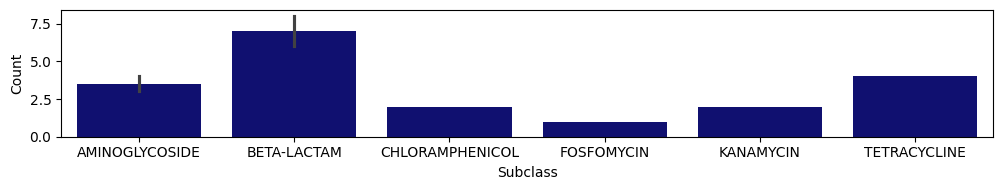

In [ ]:
# prompt: one barplot with x axis is Subclass, y axis is sample - barplots with element symbol

# Prepare data for the bar plot
# Group by Subclass and Element symbol, and count occurrences
amr_subclass_element_counts = amrfinder.groupby(['Subclass', 'Element symbol']).size().reset_index(name='Count')

# Create the bar plot
plt.figure(figsize=(10, 2))  # Adjust figure size as needed

# Create a bar plot using seaborn
sns.barplot(data=amr_subclass_element_counts, x='Subclass', y='Count', color='#000080')

# Add labels and title
plt.ylabel("Count")
#plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

# Add a legend to differentiate the element symbols
#plt.legend(title="Genes", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
amrfinder=pd.read_csv("amrfinderplus_all.tsv", sep='\t')
amrfinder

# prompt: convert amrfinder to a wide format with the sample column as the row titles, the subclass as the column titles and presence/absence
# Group by sample, Subclass, and Element symbol, and count occurrences
amr_grouped = amrfinder.groupby(['sample', 'Subclass']).size().reset_index(name='Count')
amr_grouped


,sample,Subclass,Count
0,A. insolitus aura,AMINOGLYCOSIDE,2
1,A. insolitus aura,BETA-LACTAM,3
2,A. insolitus aura,TETRACYCLINE,1
3,A. insolitus cram,AMINOGLYCOSIDE,2
4,A. insolitus cram,BETA-LACTAM,3
5,A. insolitus cram,FOSFOMYCIN,1
6,A. insolitus neet,AMINOGLYCOSIDE,1
7,A. insolitus neet,BETA-LACTAM,1
8,A. insolitus neet,KANAMYCIN,1
9,A. insolitus vya,BETA-LACTAM,1


In [ ]:
#getting a specific order
amrfinder_filtered = amr_grouped[~amr_grouped['Subclass'].str.contains('index', case=False, na=True)]

y_order=['A. insolitus aura', 'A. insolitus cram', 'A. insolitus neet',	'A. insolitus vya', 'A. xylosoxidans ayb', 'A. xylosoxidans jini', 'A. xylosoxidans suz']
amrfinder_filtered["sample"] = pd.Categorical(amrfinder_filtered["sample"], categories=y_order, ordered=True)
amrfinder_filtered

,sample,Subclass,Count
0,A. insolitus aura,AMINOGLYCOSIDE,2
1,A. insolitus aura,BETA-LACTAM,3
2,A. insolitus aura,TETRACYCLINE,1
3,A. insolitus cram,AMINOGLYCOSIDE,2
4,A. insolitus cram,BETA-LACTAM,3
5,A. insolitus cram,FOSFOMYCIN,1
6,A. insolitus neet,AMINOGLYCOSIDE,1
7,A. insolitus neet,BETA-LACTAM,1
8,A. insolitus neet,KANAMYCIN,1
9,A. insolitus vya,BETA-LACTAM,1


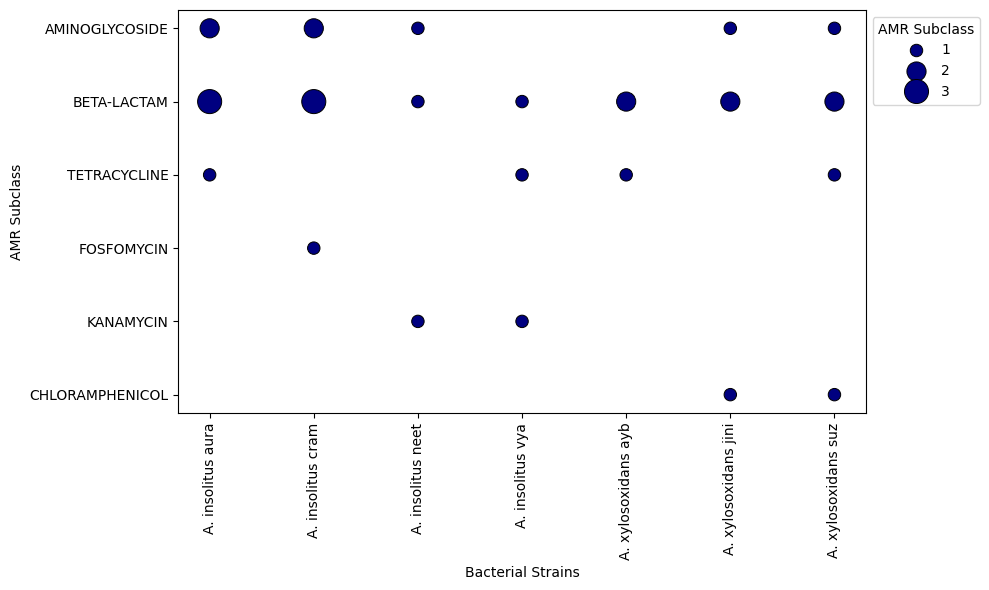

In [ ]:
# Create bubble plot
plt.figure(figsize=(10, 6))

# Create bubble plot using scatter
sns.scatterplot(
    x=amrfinder_filtered["sample"],
    y=amrfinder_filtered["Subclass"],
    size=amrfinder_filtered["Count"],
    sizes=(80, 300),
    edgecolor="black",
    alpha=1,
    color="#000080"
    #hue=amrfinder_filtered["Subclass"],
    #palette="colorblind"
)

# Customize plot aesthetics
plt.xlabel("Bacterial Strains")
plt.ylabel("AMR Subclass")
plt.xticks(rotation=90)
plt.legend(title="AMR Subclass", bbox_to_anchor=(1, 1), loc='upper left')

# Show plot
plt.tight_layout()
plt.show()

## AMR results

In [ ]:
amrtest=pd.read_csv("amrresults.csv", sep=',')
amrtest

,Antibiotic,Antibiotic subclass,A. xylosoxidans jini,A. xylosoxidans ayb,A. xylosoxidans suz,A. insolitus neet,A. insolitus aura,A. insolitus cram,A. insolitus vya,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Piperacillin/tazobactam,Antipseudomonal penicillin,S,S,S,R,R,S,S,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ticarcillin/ clavulanate,Antipseudomonal penicillin,S,S,S,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ceftazidime,Cephalosporins,S,I,S,R,I,I,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ceftriaxone,Cephalosporins,R,R,R,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Cefepime,Cephalosporins,R,R,R,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Meropenem,Carbapenems,S,S,S,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Amikacin,AMINOGLYCOSIDE,R,R,R,S,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Gentamicin,AMINOGLYCOSIDE,R,R,I,S,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Tobramycin,AMINOGLYCOSIDE,R,R,S,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Ciprofloxacin,FLUROQUINOLONE,R,R,R,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
amrtest

,Antibiotic,Antibiotic subclass,A. xylosoxidans jini,A. xylosoxidans ayb,A. xylosoxidans suz,A. insolitus neet,A. insolitus aura,A. insolitus cram,A. insolitus vya,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Piperacillin/tazobactam,Antipseudomonal penicillin,S,S,S,R,R,S,S,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ticarcillin/ clavulanate,Antipseudomonal penicillin,S,S,S,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ceftazidime,Cephalosporins,S,I,S,R,I,I,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ceftriaxone,Cephalosporins,R,R,R,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Cefepime,Cephalosporins,R,R,R,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Meropenem,Carbapenems,S,S,S,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Amikacin,AMINOGLYCOSIDE,R,R,R,S,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Gentamicin,AMINOGLYCOSIDE,R,R,I,S,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Tobramycin,AMINOGLYCOSIDE,R,R,S,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Ciprofloxacin,FLUROQUINOLONE,R,R,R,R,R,R,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Antibiotics → index, strains → columns
amr_matrix_wide = amrtest.set_index('Antibiotic')

# Orders
y_order = [
    'A. insolitus aura',
    'A. insolitus cram',
    'A. insolitus neet',
    'A. insolitus vya',
    'A. xylosoxidans ayb',
    'A. xylosoxidans jini',
    'A. xylosoxidans suz'
]

x_order = [
    'Amikacin',
    'Gentamicin',
    'Tobramycin',
    'Piperacillin/tazobactam',
    'Ticarcillin/ clavulanate',
    'Ceftriaxone',
    'Cefepime',
    'Tetracycline',
    'Ceftazidime',
    'Meropenem',
    'Ciprofloxacin',
    'Trimethoprim/sulfamethoxazole'
]

# Reorder strains (columns)
amr_matrix_reordered = amr_matrix_wide.reindex(columns=y_order)

# Transpose → strains become rows
amr_transposed = amr_matrix_reordered.T

# Enforce final row + column order
amr_transposed = amr_transposed.reindex(index=y_order, columns=x_order)
amr_transposed

,0,1,2,3,4,5,6,7,8,9,10,11
A. insolitus aura,R,R,I,R,R,R,R,R,R,R,R,R
A. insolitus cram,S,R,I,R,R,R,R,R,R,R,R,R
A. insolitus neet,R,R,R,R,R,R,S,S,R,R,R,R
A. insolitus vya,S,R,R,R,R,R,R,R,R,R,R,R
A. xylosoxidans ayb,S,S,I,R,R,S,R,R,R,R,S,R
A. xylosoxidans jini,S,S,S,R,R,S,R,R,R,R,S,R
A. xylosoxidans suz,S,S,S,R,R,S,R,I,S,R,R,R


/tmp/ipython-input-1568426116.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  amr_numerical = amr_transposed.replace({'R': 0, 'I': 1, 'S': 2})


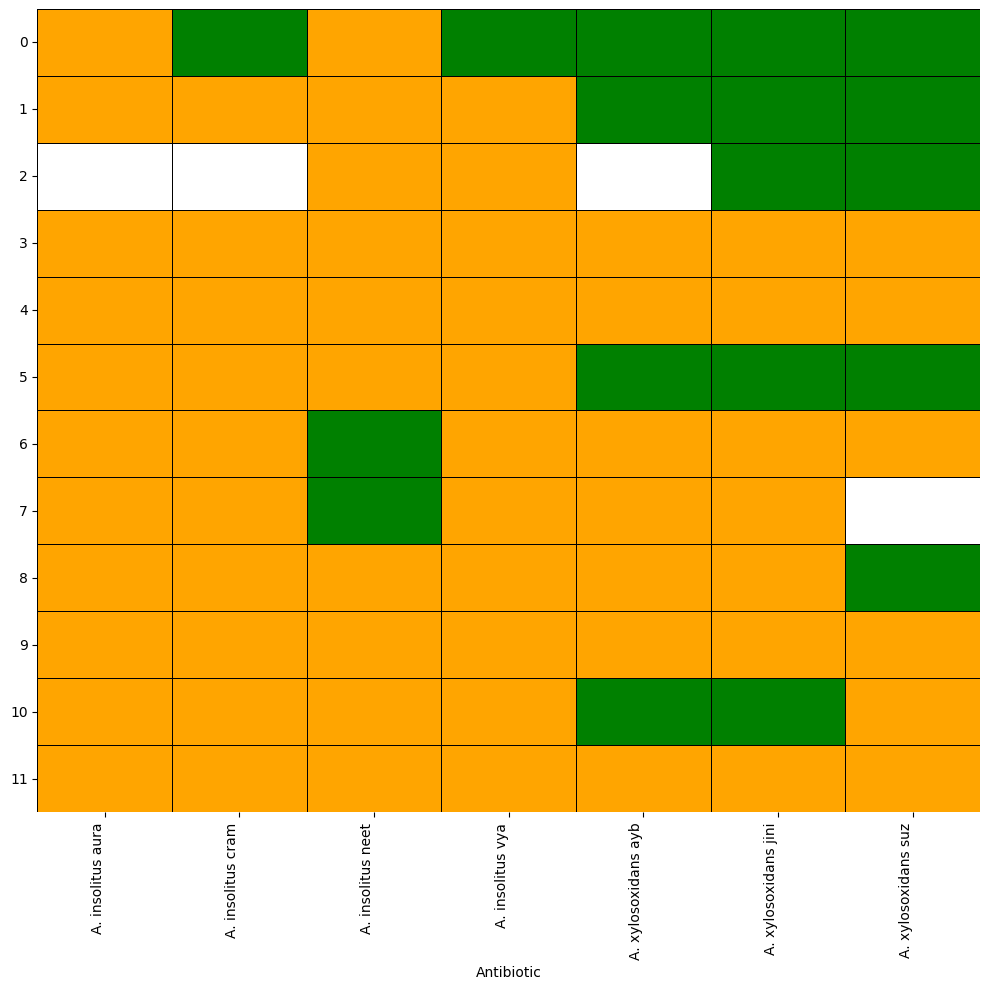

In [ ]:
# prompt: draw a heatmap of amr, but with S as green, R as red and I as white and NaN as grey
# Define the custom color map and boundaries
colors = ["orange", "grey", "green", "#9393AC"] # R, I, S, NaN
bounds = [0, 0.5, 1.5, 2.5, 3.5] # Bounds corresponding to R, I, S, NaN
cmap = plt.matplotlib.colors.ListedColormap(colors)
norm = plt.matplotlib.colors.BoundaryNorm(bounds, cmap.N)

# Convert 'R', 'I', 'S' to numerical values for the heatmap
amr_numerical = amr_transposed.replace({'R': 0, 'I': 1, 'S': 2})
amr_numerical = amr_numerical.fillna(3)

# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(amr_numerical.T, cmap=cmap, norm=norm, linewidths=.5, linecolor='black', cbar=False)
plt.xlabel('Antibiotic')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# EOP

DatFrame: `eopT`

**Also used for Figure 3 in the manuscript**

### EOP values relative to reference strain

In [ ]:
# prompt: read a file EOP.txt that is tab separated, and read the values in as scientific notation

eop = pd.read_csv('EOP_values.csv', index_col=0)
eopT= eop.T
eopT

EOP,Coliflower,Infector,Yaccob,Rage,Patchman,Viralious,Turner,Saurus,Gadget,kuwaak,ewik,maay,tuull,nyashin,kwarr
A xylosoxidans jini,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0
A xylosoxidans ayb,1,1,1,0,0,1,0,1,1,1,1,0,1,0,0
A xylosoxidans suz,1,1,0,1,1,1,0,0,1,1,1,0,1,1,0
A insolitus vya,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
A insolitus neet,1,0,1,0,0,1,0,0,1,0,1,0,1,0,0
A insolitus aura,1,0,1,1,1,1,0,0,0,0,1,0,0,0,0
A insolitus cram,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0


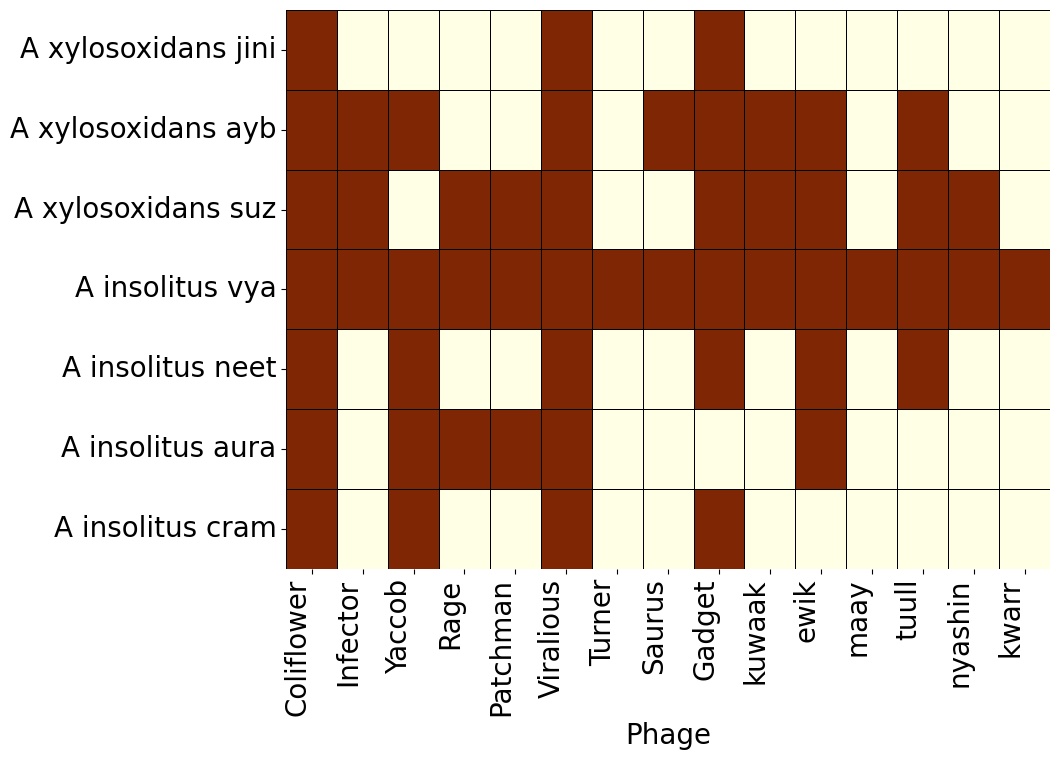

In [ ]:
# prompt: draw a heatmap of amr, but with S as green, R as red and I as white and NaN as grey
# Define the custom color map and boundaries
colors = ["#FFFFE5", "#7F2704"]
bounds = [0, 0.5] # Bounds corresponding to 0,1
cmap = colors
norm = plt.matplotlib.colors.BoundaryNorm(bounds, len(cmap))

plt.rcParams.update({'font.size': 20})  # Set a larger font size for all text elements

# Convert 'R', 'I', 'S' to numerical values for the heatmap
#eopT_numerical = eopT_transposed.replace({'R': 0, 'I': 1, 'S': 2})
#eopT_numerical = eopT_numerical.fillna(3)

# Plot the heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(eopT, cmap=cmap, norm=norm, linewidths=.5, linecolor='black', cbar=False)
plt.xlabel('Bacteria')
plt.xlabel('Phage')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

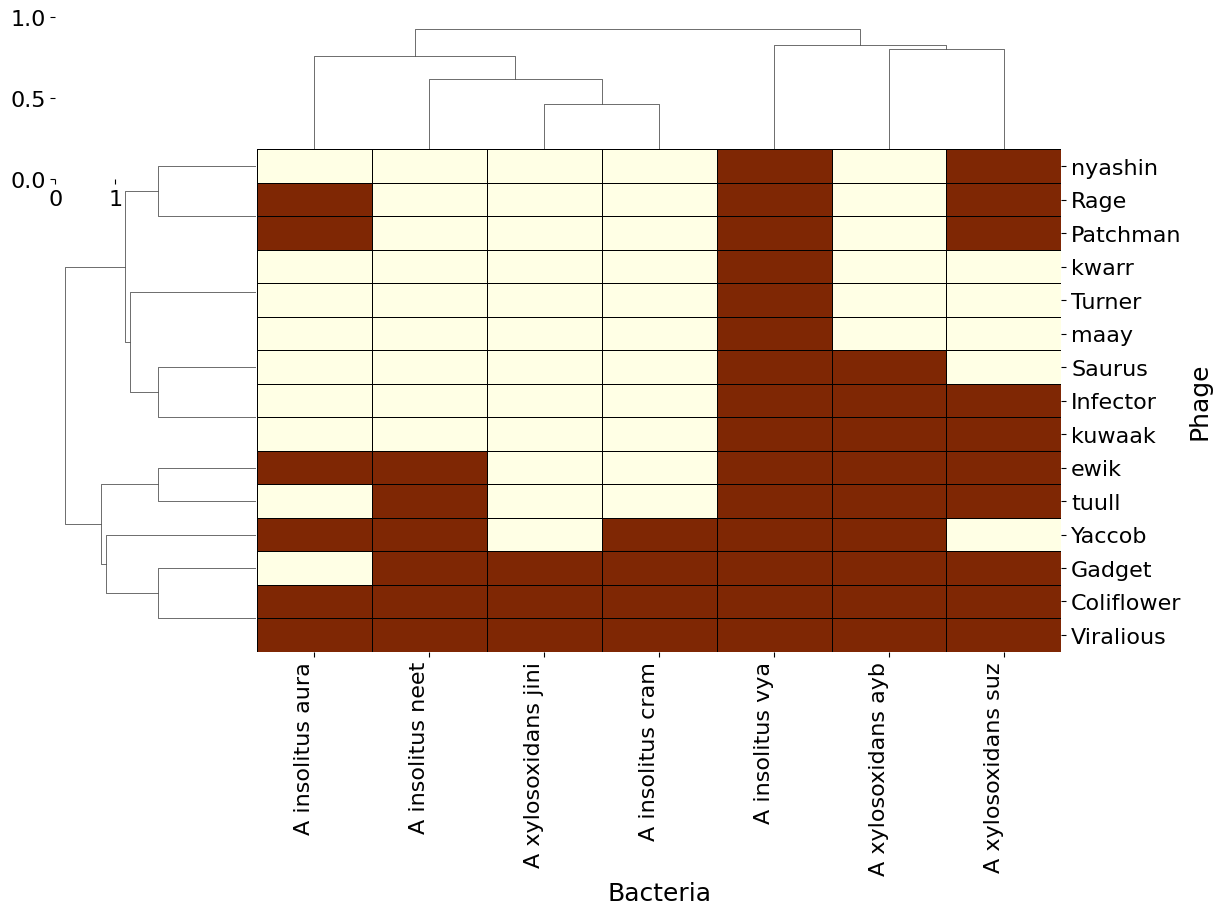

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define the categorical color map
cmap = ListedColormap([
    '#FFFFE5',  # R - light yellow
    '#FEC44F',  # I - orange
    '#7F2704',  # S - brown
])

# Map categories to numeric values for plotting
# R=0, I=1, S=2, NaN=3
eopT_numerical = eopT.replace({'R': 0, 'I': 1, 'S': 2})
eopT_numerical = eopT_numerical.fillna(3)

# Set font size
plt.rcParams.update({'font.size': 16})

# Draw clustered heatmap
g = sns.clustermap(
    eopT_numerical.T,
    cmap=cmap,
    linewidths=0.5,
    linecolor='black',
    row_cluster=True,
    col_cluster=True,
    cbar=False,
    figsize=(12, 9)
)

# Axis labels and ticks
g.ax_heatmap.set_xlabel("Bacteria", fontsize=18)
g.ax_heatmap.set_ylabel("Phage", fontsize=18)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

plt.show()


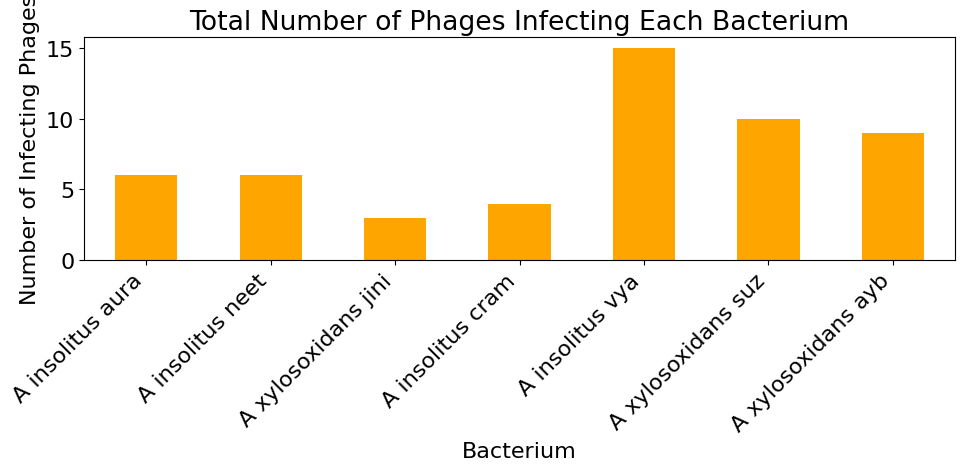

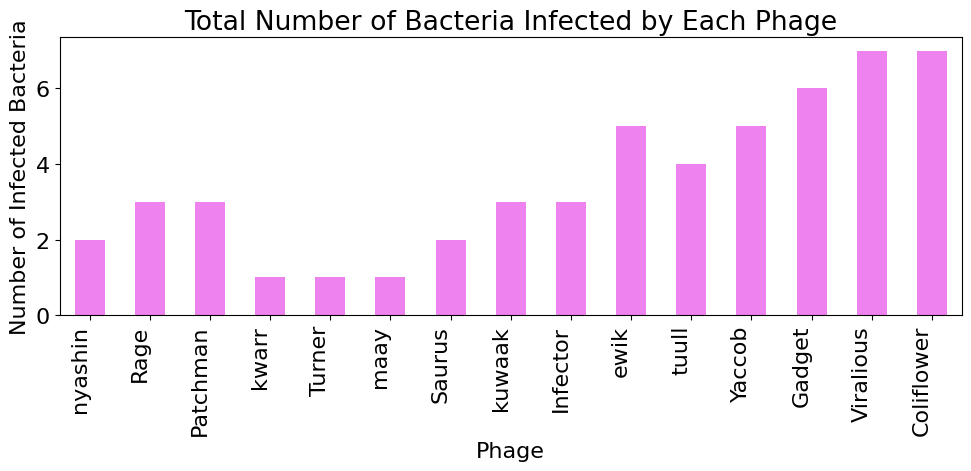

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: assuming your DataFrame is called eopT and looks like your snippet
# (first column = 'EOP' with bacterial names)
# Make sure 'EOP' is the index
#eopT = eopT.set_index('EOP')

# === 1️⃣ Totals for each bacterium (row sums)
bacteria_totals = eopT.sum(axis=1)

# === 2️⃣ Totals for each phage (column sums)
phage_totals = eopT.sum(axis=0)

# === 3️⃣ Define your custom order
# Replace these with your desired order
bacteria_order = [
    "A insolitus aura",
    "A insolitus neet",
    "A xylosoxidans jini",
    "A insolitus cram",
    "A insolitus vya",
    "A xylosoxidans suz",
    "A xylosoxidans ayb"
]

phage_order = [
    "nyashin", "Rage", "Patchman", "kwarr", "Turner", "maay", "Saurus",
    "kuwaak", "Infector", "ewik", "tuull", "Yaccob","Gadget", "Viralious",
    "Coliflower"
]

# Reorder totals according to your preference
bacteria_totals = bacteria_totals.loc[bacteria_order]
phage_totals = phage_totals.loc[phage_order]

# === 4️⃣ Plot total phages infecting each bacterium ===
plt.figure(figsize=(10, 5))
bacteria_totals.plot(kind='bar', color='orange')  # teal green
plt.title("Total Number of Phages Infecting Each Bacterium")
plt.xlabel("Bacterium")
plt.ylabel("Number of Infecting Phages")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# === 5️⃣ Plot total bacteria infected by each phage ===
plt.figure(figsize=(10, 5))
phage_totals.plot(kind='bar', color='violet')  # deep violet
plt.title("Total Number of Bacteria Infected by Each Phage")
plt.xlabel("Phage")
plt.ylabel("Number of Infected Bacteria")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()


### Plotting the EOP raw values

Log-normalised heatmap

In [ ]:
# prompt: read a file EOP.txt that is tab separated, and read the values in as scientific notation

eop_raw = pd.read_csv('eop_raw_values.csv', index_col=0)
eop_raw

,A xylosoxidans jini,A xylosoxidans ayb,A xylosoxidans suz,A insolitus vya,A insolitus neet,A insolitus aura,A insolitus cram
EOP,,,,,,,
Coliflower,1.780000e+01,3.330000e+04,8.330000e+02,1.0,1.110000e+03,3.330000e+02,5.560000e+02
Infector,2.500000e-01,1.000000e+02,1.670000e+04,1.0,2.500000e-05,8.330000e-04,1.250000e-03
Yaccob,3.750000e-04,4.500000e+02,1.750000e-02,1.0,4.500000e+00,5.000000e+00,2.500000e+00
Rage,7.690000e-08,7.690000e-03,2.150000e+00,1.0,3.080000e-03,1.310000e+00,9.230000e-01
Patchman,6.150000e-07,7.690000e-03,2.150000e+00,1.0,3.080000e-03,1.310000e+00,9.230000e-01
Viralious,1.030000e+10,4.840000e+07,1.000000e+10,1.0,9.030000e+09,8.060000e+09,7.740000e+09
Turner,4.170000e-09,2.500000e-01,8.330000e-05,1.0,1.250000e-04,1.670000e-06,2.500000e-06
Saurus,6.000000e-03,1.800000e+07,4.000000e-03,1.0,1.000000e-01,2.000000e-01,3.000000e-01
Gadget,1.670000e+00,8.330000e+01,3.000000e+02,1.0,2.500000e+00,2.170000e-01,3.670000e+00


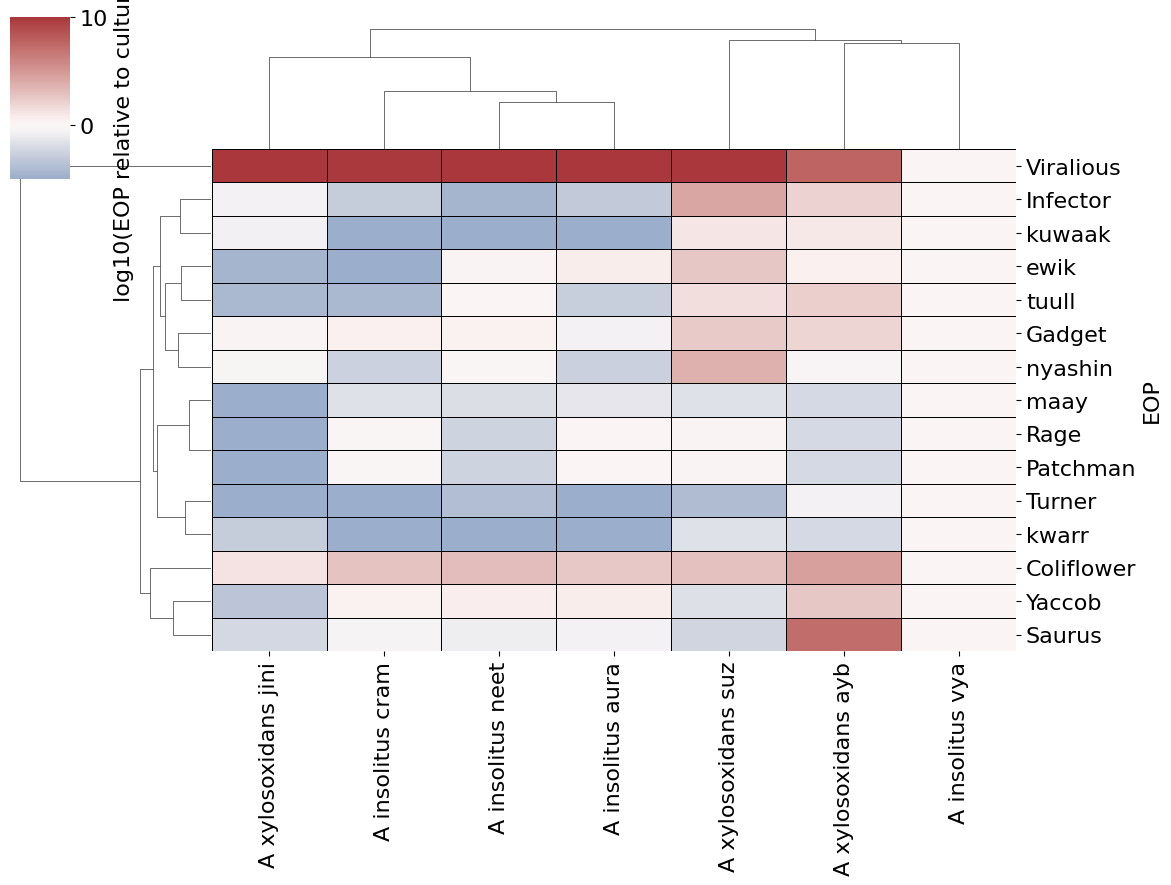

In [ ]:
from matplotlib.colors import PowerNorm
df=eop_raw
sns.clustermap(
    np.log10(df + 1e-5),
    cmap='vlag',    # diverging colormap
    center=0,       # 1x reference EOP = white
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'label': 'log10(EOP relative to culturing host)'},
    figsize=(12, 9)
)



# Phage

## ANI results

Saved in DataFrame: `pyani`

In [ ]:
cov=pd.read_csv("phages_ANIb_alignment_coverage.tab", sep ='\t')
#cov=cov.set_index(cov.columns[0])
alignment_coverage_long = pd.melt(cov, id_vars=['Unnamed: 0'], var_name='target', value_name='Coverage')
alignment_coverage_long = alignment_coverage_long.rename(columns={'Unnamed: 0': 'source'})
# Replace "_reoriented_genome" with "" in the 'source' and 'target' columns
alignment_coverage_long['source'] = alignment_coverage_long['source'].str.replace("_reoriented_genome", "")
alignment_coverage_long['target'] = alignment_coverage_long['target'].str.replace("_reoriented_genome", "")
alignment_coverage_long

,source,target,Coverage
0,coliflower,coliflower,1.000000
1,ewik,coliflower,0.539901
2,gadget,coliflower,0.861305
3,infector,coliflower,0.836392
4,kuwaak,coliflower,0.875149
...,...,...,...
220,saurus,yaccob,0.665915
221,turner,yaccob,0.653478
222,tuull,yaccob,0.000000
223,viralious,yaccob,0.977324


In [ ]:
identity=pd.read_csv("phages_ANIb_percentage_identity.tab", sep ='\t')
#identity=identity.set_index(identity.columns[0])
percentage_identity_long = pd.melt(identity, id_vars=['Unnamed: 0'], var_name='target', value_name='Identity')
percentage_identity_long = percentage_identity_long.rename(columns={'Unnamed: 0': 'source'})
percentage_identity_long['source'] = percentage_identity_long['source'].str.replace("_reoriented_genome", "")
percentage_identity_long['target'] = percentage_identity_long['target'].str.replace("_reoriented_genome", "")
percentage_identity_long

,source,target,Identity
0,coliflower,coliflower,1.000000
1,ewik,coliflower,0.962725
2,gadget,coliflower,0.959339
3,infector,coliflower,0.956864
4,kuwaak,coliflower,0.959935
...,...,...,...
220,saurus,yaccob,0.788187
221,turner,yaccob,0.785429
222,tuull,yaccob,0.000000
223,viralious,yaccob,0.998575


In [ ]:
pyani = pd.merge(percentage_identity_long, alignment_coverage_long, on=["source", "target"])
pyani

,source,target,Identity,Coverage
0,coliflower,coliflower,1.000000,1.000000
1,ewik,coliflower,0.962725,0.539901
2,gadget,coliflower,0.959339,0.861305
3,infector,coliflower,0.956864,0.836392
4,kuwaak,coliflower,0.959935,0.875149
...,...,...,...,...
220,saurus,yaccob,0.788187,0.665915
221,turner,yaccob,0.785429,0.653478
222,tuull,yaccob,0.000000,0.000000
223,viralious,yaccob,0.998575,0.977324


## Visualizing genomes

Saved to a separate notebook, that generates the Figure 2D

```
# This is formatted as code
```



## Reading in the gene matrix file

To identify the conserved genes. Generates PCA plot in Figure 2

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from itertools import chain

In [ ]:
gene_matrix=pd.read_csv('Phage_gene_matrix.csv')
gene_matrix['queryID'].unique()
gene_matrix['queryID'] = gene_matrix['queryID'].str.replace("_reoriented", "")
gene_matrix['queryID'] = gene_matrix['queryID'].str.replace("_update2", "")
gene_matrix['queryID'] = gene_matrix['queryID'].str.replace("_update3", "")
gene_matrix['refID'] = gene_matrix['refID'].str.replace("_reoriented", "")
gene_matrix['refID'] = gene_matrix['refID'].str.replace("_update2", "")
gene_matrix['refID'] = gene_matrix['refID'].str.replace("_update3", "")
gene_matrix

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,qproduct,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name
0,ewik,Ewik_contig_1,0,1134,coliflower,Coliflower_contig_1,565,1129,100.0,1.140000e-108,terminase large subunit,AXUUMYTS_CDS_0001,terminase large subunit,JDOEVDKM_CDS_0002,ewik - AXUUMYTS_CDS_0001,ewik - AXUUMYTS_CDS_0001 - terminase large sub...,coliflower - JDOEVDKM_CDS_0002,coliflower - JDOEVDKM_CDS_0002 - terminase lar...
1,ewik,Ewik_contig_1,1136,2675,coliflower,Coliflower_contig_1,1483,2524,99.1,1.130000e-231,portal protein,AXUUMYTS_CDS_0002,portal protein,JDOEVDKM_CDS_0004,ewik - AXUUMYTS_CDS_0002,ewik - AXUUMYTS_CDS_0002 - portal protein,coliflower - JDOEVDKM_CDS_0004,coliflower - JDOEVDKM_CDS_0004 - portal protein
2,ewik,Ewik_contig_1,6569,7490,coliflower,Coliflower_contig_1,6915,8250,98.2,8.050000e-186,minor tail protein,AXUUMYTS_CDS_0005,minor tail protein,JDOEVDKM_CDS_0016,ewik - AXUUMYTS_CDS_0005,ewik - AXUUMYTS_CDS_0005 - minor tail protein,coliflower - JDOEVDKM_CDS_0016,coliflower - JDOEVDKM_CDS_0016 - minor tail pr...
3,ewik,Ewik_contig_1,8062,8494,coliflower,Coliflower_contig_1,8281,8647,97.1,5.070000e-68,Tail assembly chaperone,AXUUMYTS_CDS_0007,Tail assembly chaperone,JDOEVDKM_CDS_0017,ewik - AXUUMYTS_CDS_0007,ewik - AXUUMYTS_CDS_0007 - Tail assembly chape...,coliflower - JDOEVDKM_CDS_0017,coliflower - JDOEVDKM_CDS_0017 - Tail assembly...
4,ewik,Ewik_contig_1,9743,9293,coliflower,Coliflower_contig_1,9050,9500,99.3,1.200000e-94,tail length tape measure protein,AXUUMYTS_CDS_0008,tail completion or Neck1 protein,JDOEVDKM_CDS_0020,ewik - AXUUMYTS_CDS_0008,ewik - AXUUMYTS_CDS_0008 - tail length tape me...,coliflower - JDOEVDKM_CDS_0020,coliflower - JDOEVDKM_CDS_0020 - tail completi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8629,tuull,Tuull_contig_1,30540,30756,nyashin,Nyashin_contig_1,31128,31356,80.0,2.190000e-42,transcriptional repressor,YRFTTTDG_CDS_0033,transcriptional repressor,BUBCVPIM_CDS_0047,tuull - YRFTTTDG_CDS_0033,tuull - YRFTTTDG_CDS_0033 - transcriptional re...,nyashin - BUBCVPIM_CDS_0047,nyashin - BUBCVPIM_CDS_0047 - transcriptional ...
8630,tuull,Tuull_contig_1,33967,34723,nyashin,Nyashin_contig_1,34562,35288,65.6,1.050000e-103,hypothetical protein,YRFTTTDG_CDS_0037,hypothetical protein,BUBCVPIM_CDS_0052,tuull - YRFTTTDG_CDS_0037,tuull - YRFTTTDG_CDS_0037 - hypothetical protein,nyashin - BUBCVPIM_CDS_0052,nyashin - BUBCVPIM_CDS_0052 - hypothetical pro...
8631,tuull,Tuull_contig_1,36059,36368,nyashin,Nyashin_contig_1,36699,37008,99.0,7.210000e-69,hypothetical protein,YRFTTTDG_CDS_0043,hypothetical protein,BUBCVPIM_CDS_0057,tuull - YRFTTTDG_CDS_0043,tuull - YRFTTTDG_CDS_0043 - hypothetical protein,nyashin - BUBCVPIM_CDS_0057,nyashin - BUBCVPIM_CDS_0057 - hypothetical pro...
8632,tuull,Tuull_contig_1,37196,37886,nyashin,Nyashin_contig_1,38068,38608,82.6,6.230000e-99,hypothetical protein,YRFTTTDG_CDS_0045,hypothetical protein,BUBCVPIM_CDS_0061,tuull - YRFTTTDG_CDS_0045,tuull - YRFTTTDG_CDS_0045 - hypothetical protein,nyashin - BUBCVPIM_CDS_0061,nyashin - BUBCVPIM_CDS_0061 - hypothetical pro...


/tmp/ipython-input-3970278880.py:120: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_ncar', len(unique_genomes))


('gene_content_pca_genes_points_identity.png',
 'gene_by_genome_identity_matrix.csv',
 'gene_pca_coordinates_identity.csv')

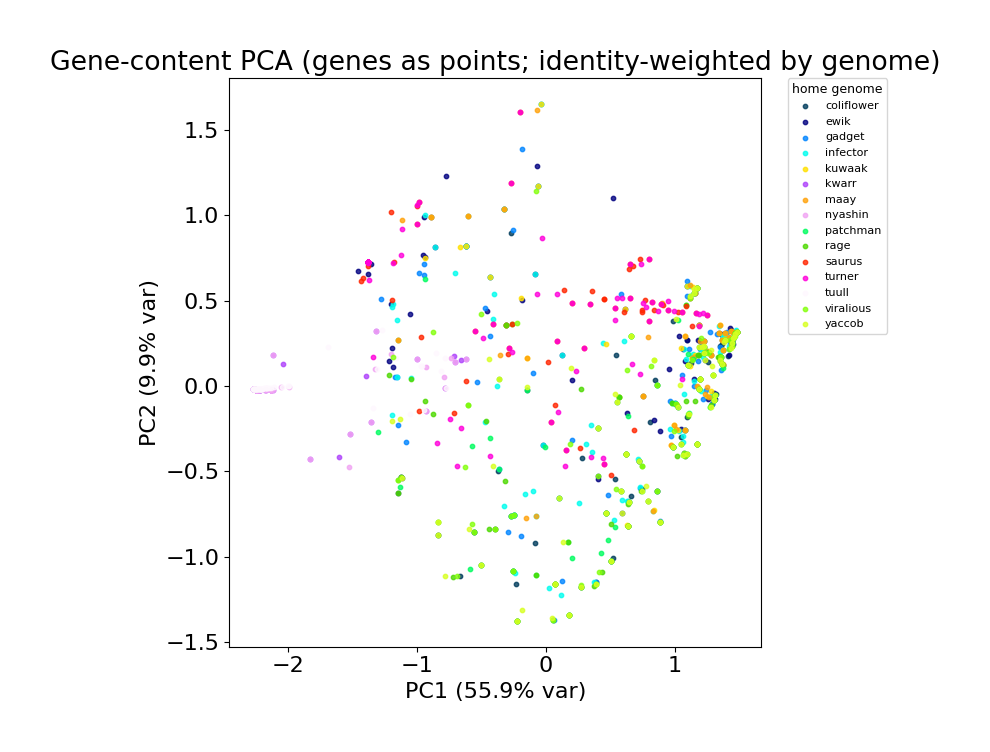

In [ ]:
# ----- Gene-content PCA with identity-weighted similarities (genes as points) -----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

# ===== Load data =====
df = gene_matrix  # <- your original dataframe with pairwise alignments

# Columns we’ll use:
# - gene ids (query/ref): 'merged_query' & 'merged_ref' (fallback to qgeneID/rgeneID)
# - genome ids (query/ref): 'queryID' & 'refID'
# - identity column: we’ll try common names and pick the first that exists
gene_query_col = 'merged_query' if 'merged_query' in df.columns else ('qgeneID' if 'qgeneID' in df.columns else None)
gene_ref_col   = 'merged_ref'   if 'merged_ref'   in df.columns else ('rgeneID' if 'rgeneID' in df.columns else None)
if gene_query_col is None or gene_ref_col is None:
    raise ValueError("Couldn't find gene ID columns. Expected 'merged_query'/'merged_ref' (or qgeneID/rgeneID).")

genome_query_col = 'queryID'
genome_ref_col   = 'refID'

# Try to locate an identity column (percentage or fraction)
possible_ident_cols = ['identity']
ident_col = next((c for c in possible_ident_cols if c in df.columns), None)
if ident_col is None:
    raise ValueError(f"Couldn't find identity column; tried: {possible_ident_cols}")

# Normalize identity to [0,1] if it looks like percent
ident_vals = df[ident_col].astype(float)
if ident_vals.max() > 1.5:  # assume it's 0–100%
    df['_ident01'] = ident_vals / 100.0
else:
    df['_ident01'] = ident_vals.clip(lower=0, upper=1)

# ===== Build gene list and home genomes =====
genes_q = df[[gene_query_col, genome_query_col]].drop_duplicates().rename(
    columns={gene_query_col: 'gene_id', genome_query_col: 'home_genome'}
)
genes_r = df[[gene_ref_col, genome_ref_col]].drop_duplicates().rename(
    columns={gene_ref_col: 'gene_id', genome_ref_col: 'home_genome'}
)
all_genes = pd.concat([genes_q, genes_r], ignore_index=True).drop_duplicates(subset=['gene_id'])

def extract_home_genome(gene_id, fallback):
    if isinstance(gene_id, str) and ' - ' in gene_id:
        return gene_id.split(' - ')[0].strip()
    return fallback

all_genes['home_genome'] = [
    extract_home_genome(gi, hg) for gi, hg in zip(all_genes['gene_id'], all_genes['home_genome'])
]

all_genomes = sorted(set(df[genome_query_col]).union(set(df[genome_ref_col])))
gene_index = all_genes['gene_id'].tolist()

# ===== Build identity-weighted gene × genome matrix =====
# Strategy:
#   For each alignment row:
#     - record similarity for (query gene -> ref genome)
#     - record similarity for (ref gene -> query genome)
#   If multiple hits per (gene, genome), keep max identity.
#   Set self (gene, home_genome) = max(existing, 1.0)

# Start empty long-form accumulator
records = []

# query-side contributions: q_gene has a homolog in r_home with identity
tmp_q = df[[gene_query_col, genome_ref_col, '_ident01']].copy()
tmp_q.columns = ['gene_id', 'target_genome', 'ident01']
records.append(tmp_q)

# ref-side contributions: r_gene has a homolog in q_home with identity
tmp_r = df[[gene_ref_col, genome_query_col, '_ident01']].copy()
tmp_r.columns = ['gene_id', 'target_genome', 'ident01']
records.append(tmp_r)

long_df = pd.concat(records, ignore_index=True).dropna(subset=['gene_id', 'target_genome'])

# Reduce to max identity per (gene, genome)
long_max = (long_df
            .groupby(['gene_id', 'target_genome'], as_index=False)['ident01']
            .max())

# Pivot to wide matrix; initialize missing with 0 (no hit)
G = long_max.pivot(index='gene_id', columns='target_genome', values='ident01').reindex(
    index=gene_index, columns=all_genomes
)
G = G.fillna(0.0).astype(np.float32)

# Ensure self-similarity is 1.0 for each gene’s home genome
home_map = dict(zip(all_genes['gene_id'], all_genes['home_genome']))
for gi, hg in home_map.items():
    if gi in G.index and hg in G.columns:
        if np.isnan(G.at[gi, hg]):
            G.at[gi, hg] = 1.0
        else:
            G.at[gi, hg] = max(G.at[gi, hg], 1.0)

# Optionally drop genomes with zero variance and genes with all zeros
G = G.loc[(G.sum(axis=1) > 0)]
G = G.loc[:, G.var(axis=0) > 0]

# ===== PCA =====
# Center columns (genomes) but don’t scale to unit variance; this keeps it close to correspondence/CA-ish feel.
scaler = StandardScaler(with_mean=True, with_std=False)
X = scaler.fit_transform(G.values)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

# ===== Plotting frame =====
plot_df = (pd.DataFrame({'gene_id': G.index, 'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1]})
           .merge(all_genes[['gene_id', 'home_genome']], on='gene_id', how='left'))

# ===== Colors by home genome =====
unique_genomes = plot_df['home_genome'].dropna().unique().tolist()
cmap = cm.get_cmap('gist_ncar', len(unique_genomes))
genome_to_color = {g: cmap(i) for i, g in enumerate(unique_genomes)}
plot_df['color'] = plot_df['home_genome'].map(genome_to_color)

# ===== Plot =====
plt.figure(figsize=(8, 7))
for g, sub in plot_df.groupby('home_genome'):
    plt.scatter(sub['PC1'], sub['PC2'], s=10, alpha=0.8,
                label=g, c=[genome_to_color.get(g, (0.5, 0.5, 0.5))])

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Gene-content PCA (genes as points; identity-weighted by genome)")

max_labels = 25
handles, labels = plt.gca().get_legend_handles_labels()
if len(labels) > max_labels:
    handles = handles[:max_labels]
    labels = labels[:max_labels]
    legend_title = f"home genome (first {max_labels} shown of {len(unique_genomes)})"
else:
    legend_title = "home genome"
plt.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.05, 1),
           loc='upper left', borderaxespad=0.0, fontsize=8, title_fontsize=9)
plt.tight_layout()

# ===== Save outputs =====
png_path = "gene_content_pca_genes_points_identity.png"
plt.savefig(png_path, dpi=200, bbox_inches='tight')

matrix_path = "gene_by_genome_identity_matrix.csv"
coords_path = "gene_pca_coordinates_identity.csv"
G.to_csv(matrix_path)
plot_df[['gene_id', 'home_genome', 'PC1', 'PC2']].to_csv(coords_path, index=False)

png_path, matrix_path, coords_path


In [ ]:
# --- build phage-level network ---
G = nx.Graph()
for _, row in gene_matrix.iterrows():
    q, r = row["queryID"], row["refID"]
    if q != r:
        G.add_edge(q, r)

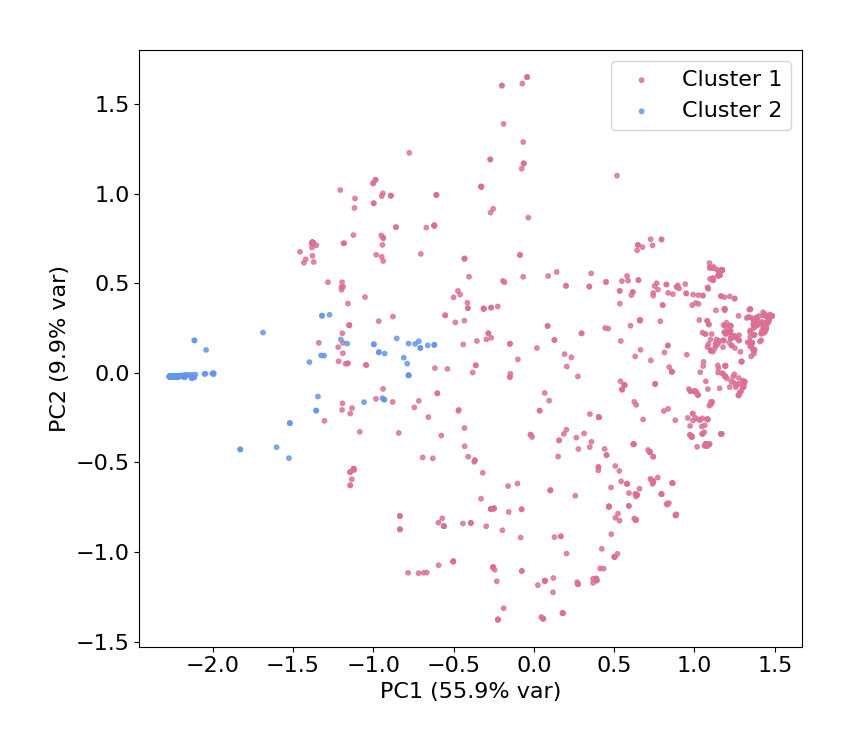

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# pick which clusters to highlight
cluster1 = ['coliflower', 'ewik', 'gadget', 'infector', 'kuwaak', 'maay', 'patchman', 'rage', 'saurus', 'turner', 'viralious', 'yaccob']
cluster2 = ['kwarr', 'nyashin', 'tuull']   # first cluster

def normalize_name(name: str) -> str:
    if isinstance(name, str):
        return name.split("_")[0].lower()  # take the part before first underscore
    return name

# normalized cluster lists
cluster1_norm = [normalize_name(g) for g in cluster1]
cluster2_norm = [normalize_name(g) for g in cluster2]

# assign each gene to cluster
def assign_cluster(genome):
    g_norm = normalize_name(genome)
    if g_norm in cluster1_norm:
        return "Cluster 1"
    elif g_norm in cluster2_norm:
        return "Cluster 2"
    else:
        return "Other"

plot_df["cluster_group"] = plot_df["home_genome"].map(assign_cluster)


# assign colors
colors = {"Cluster 1": "palevioletred", "Cluster 2": "cornflowerblue", "Other": "gray"}
plot_df["color"] = plot_df["cluster_group"].map(colors)

# plot
plt.figure(figsize=(8,7))
for g, sub in plot_df.groupby("cluster_group"):
    plt.scatter(sub["PC1"], sub["PC2"], s=10, alpha=0.8, c=sub["color"], label=g)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
#plt.title("Similarity-weighted PCA (genes as points; colored by Cluster 1 vs Cluster 2)")
plt.legend()
plt.tight_layout()

#plt.savefig("similarity_weighted_pca_clusters1_vs2.png", dpi=200)
plt.show()



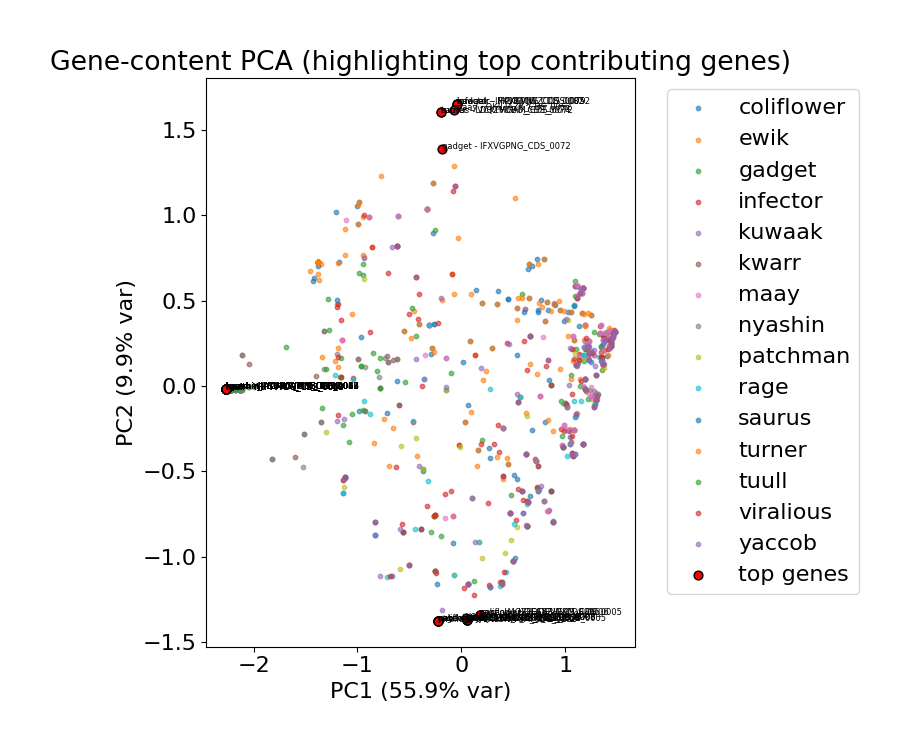

In [ ]:
#rank genes by their absolute PC1 value
topN = 20  # or whatever number you want
top_genes_pc1 = (
    plot_df
    .reindex(plot_df['PC1'].abs().sort_values(ascending=False).index)
    .head(topN)
)

#rank genes by their absolute PC1 value
topN = 20  # or whatever number you want
top_genes_pc2 = (
    plot_df
    .reindex(plot_df['PC2'].abs().sort_values(ascending=False).index)
    .head(topN)
)

# show in notebook
top_genes_pc1[['gene_id', 'home_genome', 'PC1']]
top_genes_pc2[['gene_id', 'home_genome', 'PC2']]

plt.figure(figsize=(8,7))
for g, sub in plot_df.groupby('home_genome'):
    plt.scatter(sub['PC1'], sub['PC2'], s=10, alpha=0.6, label=g)

# highlight top PC1/PC2 genes
highlight = pd.concat([top_genes_pc1, top_genes_pc2]).drop_duplicates()
plt.scatter(highlight['PC1'], highlight['PC2'], c='red', s=40, edgecolor='black', label='top genes')

for _, row in highlight.iterrows():
    plt.text(row['PC1'], row['PC2'], row['gene_id'], fontsize=6)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Gene-content PCA (highlighting top contributing genes)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
#plt.savefig("gene_pca_with_top_genes.png", dpi=200, bbox_inches='tight')


In [ ]:
top_genes_pc1_merged=top_genes_pc1.merge(gene_matrix, left_on='gene_id', right_on='merged_query')
top_genes_pc1_merged['qproduct'].unique(), top_genes_pc1_merged['rproduct'].unique()

(array(['hypothetical protein', 'DksA-like zinc-finger protein',
        'tail chaperonin', 'Rz-like spanin',
        'Sak4-like ssDNA annealing protein'], dtype=object),
 array(['hypothetical protein', 'DksA-like zinc-finger protein',
        'tail chaperonin', 'Rz-like spanin', 'tail terminator',
        'Sak4-like ssDNA annealing protein'], dtype=object))

In [ ]:
top_genes_pc1_merged['queryID'].unique(), top_genes_pc1_merged['refID'].unique()

(array(['kwarr', 'nyashin', 'tuull'], dtype=object),
 array(['nyashin', 'tuull', 'kwarr'], dtype=object))

In [ ]:
top_genes_pc2_merged=top_genes_pc2.merge(gene_matrix, left_on='gene_id', right_on='merged_query')
top_genes_pc2_merged['qproduct'].unique(), top_genes_pc2_merged['rproduct'].unique()

(array(['hypothetical protein', 'head scaffolding protein',
        'portal protein'], dtype=object),
 array(['hypothetical protein', 'portal protein',
        'head scaffolding protein'], dtype=object))

In [ ]:
top_genes_pc2_merged['queryID'].unique(), top_genes_pc2_merged['refID'].unique()

(array(['kuwaak', 'gadget', 'infector', 'maay', 'saurus', 'turner',
        'patchman', 'coliflower', 'rage', 'viralious', 'yaccob'],
       dtype=object),
 array(['ewik', 'gadget', 'infector', 'maay', 'saurus', 'turner', 'kuwaak',
        'coliflower', 'rage', 'viralious', 'yaccob', 'patchman', 'kwarr',
        'nyashin'], dtype=object))

In [ ]:
def _pick_product_column(df: pd.DataFrame, prefer_q: bool = True) -> pd.Series:
    have_q = 'qproduct' in df.columns
    have_r = 'rproduct' in df.columns
    if prefer_q:
        x_series = (df['qproduct'] if have_q else pd.Series([np.nan]*len(df)))
        fallback = (df['rproduct'] if have_r else pd.Series([np.nan]*len(df)))
    else:
        x_series = (df['rproduct'] if have_r else pd.Series([np.nan]*len(df)))
        fallback = (df['qproduct'] if have_q else pd.Series([np.nan]*len(df)))
    out = x_series.fillna(fallback)
    return out.fillna('Unknown_product')

def build_counts_both(pc1_df: pd.DataFrame,
                      pc2_df: pd.DataFrame,
                      cluster_col: str = 'cluster_group',
                      prefer_q: bool = True,
                      top_n: int = 30) -> pd.DataFrame:
    if pc1_df is None or pc1_df.empty:
        raise ValueError("pc1_df is empty or None")
    if pc2_df is None or pc2_df.empty:
        raise ValueError("pc2_df is empty or None")
    if cluster_col not in pc1_df.columns or cluster_col not in pc2_df.columns:
        raise KeyError(f"Missing '{cluster_col}' in input dataframes.")

    pc1_tmp = pc1_df.copy()
    pc2_tmp = pc2_df.copy()
    pc1_tmp['x_product'] = _pick_product_column(pc1_tmp, prefer_q=prefer_q)
    pc2_tmp['x_product'] = _pick_product_column(pc2_tmp, prefer_q=prefer_q)
    pc1_tmp['source'] = 'PC1'
    pc2_tmp['source'] = 'PC2'

    both = pd.concat([pc1_tmp[['x_product', cluster_col, 'source']],
                      pc2_tmp[['x_product', cluster_col, 'source']]], ignore_index=True)

    # long counts
    counts = (both
              .groupby(['x_product', 'source', cluster_col])
              .size()
              .rename('count')
              .reset_index())

    # wide table: index=product, columns=(source, cluster)
    wide = counts.pivot_table(index='x_product',
                              columns=['source', cluster_col],
                              values='count',
                              fill_value=0).sort_index(axis=1)

    # remove any product entries that contain "hypothetical protein"
    #mask = ~wide.index.str.contains("hypothetical protein", case=False, na=False)
    #wide = wide.loc[mask]

    # keep top_n products by total count
    totals = wide.sum(axis=1).sort_values(ascending=False)
    if top_n is not None and len(totals) > top_n:
        wide = wide.loc[totals.head(top_n).index]

    return wide, counts

def plot_counts_both(wide: pd.DataFrame,
                     #title: str = "Counts per product by cluster (PC1 & PC2)",
                     outfile_png: str = "PC1_PC2_product_counts_by_cluster.png",
                     outfile_csv: str = "PC1_PC2_product_counts_by_cluster.csv"):
    wide.to_csv(outfile_csv, index=True)

    # Column order: PC1 – Cluster1, PC1 – Cluster2, PC2 – Cluster1, PC2 – Cluster2 (if present)
    col_levels = wide.columns
    sources = sorted({lvl[0] for lvl in col_levels}, key=lambda x: (x != 'PC1', x))
    clusters = sorted({lvl[1] for lvl in col_levels})  # alphabetical/lexicographic
    ordered_cols, ordered_labels = [], []
    for src in sources:
        for cl in clusters:
            col = (src, cl)
            if col in col_levels:
                ordered_cols.append(col)
                ordered_labels.append(f"{src} – {cl}")

    products = wide.index.tolist()
    x = np.arange(len(products))
    k = len(ordered_cols)
    width = 0.8 / max(1, k)

    # define a color map for cluster labels
    cluster_colors = {
        "Cluster 1": "palevioletred",
        "Cluster 2": "cornflowerblue",
        # add more if you have them
    }

    plt.figure(figsize=(max(10, len(products) * 0.8), 6))
    for i, col in enumerate(ordered_cols):
      y = wide[col].values
      source, cluster = col  # col is a tuple (PC source, cluster)
      color = cluster_colors.get(cluster, None)  # default if not in dict
      plt.bar(x + i*width, y, width, label=ordered_labels[i], color=color)


    plt.xticks(x + (k-1)*width/2, products, rotation=75, ha='right')
    plt.ylabel("Count")
    plt.xlabel("Product (qproduct preferred; fallback rproduct)")
    #plt.title(title)
    plt.legend(title="Cluster", ncol=2)
    plt.tight_layout()
    plt.savefig(outfile_png, dpi=200, bbox_inches='tight')
    plt.close()

    return outfile_csv, outfile_png


# ---- run (expects your two merged DataFrames to exist) ----
wide, _ = build_counts_both(top_genes_pc1_merged, top_genes_pc2_merged,
                            cluster_col='cluster_group', prefer_q=True, top_n=20)
out_csv, out_png = plot_counts_both(
    wide,
    #title="Top-gene products by cluster (PC1 & PC2, side-by-side)",
    outfile_png="PC1_PC2_product_counts_by_cluster.png",
    outfile_csv="PC1_PC2_product_counts_by_cluster.csv"
)
out_png

#print("Saved:", out_csv, out_png)


'PC1_PC2_product_counts_by_cluster.png'

In [ ]:
# ============================================
# Counts per product by cluster (PC1 & PC2)
# + normalisation by *total genes per cluster*
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- helper: pick one product column ----------
def _pick_product_column(df: pd.DataFrame, prefer_q: bool = True) -> pd.Series:
    """
    Choose a product label per row, preferring qproduct then rproduct.
    Falls back to 'Unknown_product' if both are missing.
    """
    have_q = 'qproduct' in df.columns
    have_r = 'rproduct' in df.columns
    if prefer_q:
        x_series = (df['qproduct'] if have_q else pd.Series([np.nan]*len(df), index=df.index))
        fallback = (df['rproduct'] if have_r else pd.Series([np.nan]*len(df), index=df.index))
    else:
        x_series = (df['rproduct'] if have_r else pd.Series([np.nan]*len(df), index=df.index))
        fallback = (df['qproduct'] if have_q else pd.Series([np.nan]*len(df), index=df.index))
    out = x_series.fillna(fallback)
    return out.fillna('Unknown_product')


# ---------- core: build raw + normalised-by-gene-totals ----------
def build_counts_both(pc1_df: pd.DataFrame,
                      pc2_df: pd.DataFrame,
                      cluster_col: str = 'cluster_group',
                      prefer_q: bool = True,
                      top_n: int = 30):
    """
    Returns:
      wide_counts : raw counts table (index=product, columns=(source, cluster))
      wide_norm   : counts divided by *total number of genes* in that (source, cluster)
      counts_long : long table [x_product, source, cluster, count]
      denoms      : 1-row DataFrame with total genes per (source, cluster)
    """
    # --- basic checks
    if pc1_df is None or pc1_df.empty:
        raise ValueError("pc1_df is empty or None")
    if pc2_df is None or pc2_df.empty:
        raise ValueError("pc2_df is empty or None")
    if cluster_col not in pc1_df.columns or cluster_col not in pc2_df.columns:
        raise KeyError(f"Missing '{cluster_col}' in input dataframes.")

    # --- prepare & pick product string used for grouping
    pc1_tmp = pc1_df.copy()
    pc2_tmp = pc2_df.copy()
    pc1_tmp['x_product'] = _pick_product_column(pc1_tmp, prefer_q=prefer_q)
    pc2_tmp['x_product'] = _pick_product_column(pc2_tmp, prefer_q=prefer_q)
    pc1_tmp['source'] = 'PC1'
    pc2_tmp['source'] = 'PC2'

    # --- concat for counting
    both = pd.concat(
        [pc1_tmp[['x_product', cluster_col, 'source']],
         pc2_tmp[['x_product', cluster_col, 'source']]],
        ignore_index=True
    )

    # --- long counts (raw number of genes per product x source x cluster)
    counts_long = (
        both
        .groupby(['x_product', 'source', cluster_col])
        .size()
        .rename('count')
        .reset_index()
        .rename(columns={cluster_col: 'cluster'})
    )

    # --- wide counts (raw)
    wide_counts = (
        counts_long
        .pivot_table(index='x_product',
                     columns=['source', 'cluster'],
                     values='count',
                     fill_value=0)
        .sort_index(axis=1)
    )

    # --- compute denominators: total number of genes per (source, cluster)
    #     This is literally the number of rows in that source/cluster in your merged tables.
    #     We compute separately for PC1 and PC2, then align to the wide columns.
    genes_per_cluster_pc1 = pc1_tmp.groupby(cluster_col).size().astype(float)  # total genes in PC1 per cluster
    genes_per_cluster_pc2 = pc2_tmp.groupby(cluster_col).size().astype(float)  # total genes in PC2 per cluster

    # Build a 1-row DataFrame with the same MultiIndex columns as wide_counts
    denom_dict = {}
    for (src, cl) in wide_counts.columns:
        if src == 'PC1':
            denom_dict[(src, cl)] = genes_per_cluster_pc1.get(cl, np.nan)
        else:  # 'PC2'
            denom_dict[(src, cl)] = genes_per_cluster_pc2.get(cl, np.nan)

    denoms = pd.DataFrame([denom_dict])  # shape (1, n_cols)
    # Broadcast to match wide_counts' index (products)
    denoms_broadcast = pd.concat([denoms]*len(wide_counts), ignore_index=True)
    denoms_broadcast.index = wide_counts.index
    denoms_broadcast = denoms_broadcast[wide_counts.columns]  # ensure exact same column order

    # --- normalise: fraction of genes within each (source, cluster)
    with np.errstate(divide='ignore', invalid='ignore'):
        wide_norm = (wide_counts / denoms_broadcast).fillna(0.0)

    # --- keep top_n products (by raw totals so you don’t bias selection by denominator size)
    if top_n is not None and top_n > 0 and len(wide_counts) > top_n:
        totals = wide_counts.sum(axis=1).sort_values(ascending=False)
        keep_idx = totals.head(top_n).index
        wide_counts = wide_counts.loc[keep_idx]
        wide_norm   = wide_norm.loc[keep_idx]

    return wide_counts, wide_norm, counts_long, denoms


# ---------- plotting (works for raw or normalised) ----------
def plot_counts_both(wide: pd.DataFrame,
                     outfile_png: str = "PC1_PC2_product_counts_by_cluster.png",
                     outfile_csv: str = "PC1_PC2_product_counts_by_cluster.csv",
                     y_mode: str = "count",  # "count" or "fraction"
                     cluster_colors: dict | None = None):
    """
    Plot a wide table produced by build_counts_both.
      y_mode="count"    -> raw counts
      y_mode="fraction" -> fraction of genes in that (source, cluster)
    """
    # save the plotted values
    wide.to_csv(outfile_csv, index=True)

    # ordering: sources first (PC1 then PC2), then clusters alphabetically
    col_levels = wide.columns
    sources = sorted({lvl[0] for lvl in col_levels}, key=lambda x: (x != 'PC1', x))
    clusters = sorted({lvl[1] for lvl in col_levels})
    ordered_cols, ordered_labels = [], []
    for src in sources:
        for cl in clusters:
            col = (src, cl)
            if col in col_levels:
                ordered_cols.append(col)
                ordered_labels.append(f"{src} – {cl}")

    products = wide.index.tolist()
    x = np.arange(len(products))
    k = len(ordered_cols)
    width = 0.8 / max(1, k)

    plt.figure(figsize=(max(10, len(products) * 0.8), 6))
    for i, col in enumerate(ordered_cols):
        y = wide[col].values
        # optional consistent colors by cluster label
        color = None
        if cluster_colors is not None:
            _, cluster = col
            color = cluster_colors.get(cluster, None)
        plt.bar(x + i*width, y, width, label=ordered_labels[i], color=color)

    plt.xticks(x + (k-1)*width/2, products, rotation=75, ha='right')
    if y_mode == "fraction":
        plt.ylabel("Fraction of genes within (source, cluster)")
    else:
        plt.ylabel("Count")
    plt.xlabel("Product (qproduct preferred; fallback rproduct)")
    plt.legend(title="Source – Cluster", ncol=2)
    plt.tight_layout()
    plt.savefig(outfile_png, dpi=200, bbox_inches='tight')
    plt.close()

    return outfile_csv, outfile_png


# ---------- example run ----------
# assumes top_genes_pc1_merged and top_genes_pc2_merged exist in memory
# 1) build both raw counts and normalised (by total genes in cluster)
#    (normalised here is a *fraction* of genes per (PC, cluster))
wide_counts, wide_norm, counts_long, denoms = build_counts_both(
    top_genes_pc1_merged, top_genes_pc2_merged,
    cluster_col='cluster_group',
    prefer_q=True,
    top_n=20
)

# 2a) plot raw counts
plot_counts_both(
    wide_counts,
    outfile_png="PC1_PC2_product_counts_by_cluster.png",
    outfile_csv="PC1_PC2_product_counts_by_cluster.csv",
    y_mode="count",
    cluster_colors={
        "Cluster 1": "palevioletred",
        "Cluster 2": "cornflowerblue",
        # add more if needed
    }
)

# 2b) plot fractions (normalised by total genes per (PC, cluster))
plot_counts_both(
    wide_norm,
    outfile_png="PC1_PC2_product_fractions_by_cluster.png",
    outfile_csv="PC1_PC2_product_fractions_by_cluster.csv",
    y_mode="fraction",
    cluster_colors={
        "Cluster 1": "palevioletred",
        "Cluster 2": "cornflowerblue",
    }
)


('PC1_PC2_product_fractions_by_cluster.csv',
 'PC1_PC2_product_fractions_by_cluster.png')